# Notebook 6 — Ablation par $c$ constant

**Objectif :** Entraîner un **second cVAE** (même architecture FiLM, mêmes données, même budget compute)
mais avec $c = 0.5$ constant pour toutes les images pendant l'entraînement.

Puis comparer les reconstructions de :
- **cVAE(c réel)** : entraîné avec les vrais scores de qualité (checkpoint du NB04)
- **cVAE(c=0.5)** : entraîné avec un signal non-informatif (entraîné ici)

**Pourquoi c'est rigoureux :**

| Aspect | cVAE(c réel) | cVAE(c=0.5) |
|---|---|---|
| Architecture | FiLM (identique) | FiLM (identique) |
| Données | ARCADE train (identique) | ARCADE train (identique) |
| Budget compute | 7 500 steps (identique) | 7 500 steps (identique) |
| Hyperparamètres | Identiques | Identiques |
| Signal c à l'entraînement | Vrai score qualité | 0.5 pour tout |

→ Toute différence de performance est **exclusivement attribuable à la qualité du signal $c$** :
les poids appris sont différents uniquement parce que le signal d'entraînement diffère.

## 0. Configuration

In [1]:
from pathlib import Path
from pipeline_config import APPROACH, print_approach_summary

print_approach_summary()

NOTEBOOK_DIR  = Path(".").resolve()
PROJECT_ROOT  = Path("/home/infres/nadiedjoa-24/projet_IM06")

OUTPUT_DIR = Path(f"outputs_theophile/06_Ablation_c_Constant/approach_{APPROACH}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NB03_DIR       = Path("outputs_theophile/03_Inductive_Bias_Generation")
NB04_DIR       = Path(f"outputs_theophile/04_MedVAE_Architecture_Mod/approach_{APPROACH}")
LABELS_CSV     = NB03_DIR / "labels_quality.csv"
CVAE_REAL_CKPT = NB04_DIR / "quality_aware_vae.pt"  # cVAE entraîné avec c réel

PRETRAINED_DIR = Path("outputs_theophile/pretrained_weights")
PHASE1_CKPT    = PRETRAINED_DIR / "vae_4x_4c_2D.ckpt"  # poids MedVAE pré-entraînés

CVAE_CONST_CKPT = OUTPUT_DIR / "quality_aware_vae_c_constant.pt"  # sera produit ici

# Config modèle (identique au NB04)
DDCONFIG = {
    "double_z": True, "z_channels": 4, "resolution": 64,
    "in_channels": 1, "out_ch": 1, "ch": 128,
    "ch_mult": [1, 2, 4], "num_res_blocks": 2,
    "attn_resolutions": [], "dropout": 0.0,
}
EMBED_DIM = 4
IMG_SIZE  = DDCONFIG["resolution"]

# Config entraînement (identique au NB04)
N_WARMUP_STEPS   = 2_500
WARMUP_LR        = 4.5e-6
N_FINETUNE_STEPS = 5_000
FINETUNE_LR      = 1e-6
BATCH_SIZE       = 4
KL_WEIGHT        = 1e-6
VAL_EVERY        = 250
PATIENCE         = 10

# Le c constant utilisé pendant l'entraînement
C_CONSTANT = 0.5

# Évaluation
N_TEST_PER_CLASS = 20
RANDOM_SEED      = 42

print(f"Checkpoint c réel   : {CVAE_REAL_CKPT}  (existe: {CVAE_REAL_CKPT.exists()})")
print(f"Checkpoint c const  : {CVAE_CONST_CKPT}")
print(f"Labels              : {LABELS_CSV}  (existe: {LABELS_CSV.exists()})")
print(f"c constant (entraînement) : {C_CONSTANT}")
print(f"Budget total : {N_WARMUP_STEPS + N_FINETUNE_STEPS} steps")

╔══════════════════════════════════════════════════════════╗
║  Approche : B — PCA (PC1)                                   ║
╚══════════════════════════════════════════════════════════╝
  Colonne de score : score_pca
  Premier composant principal normalisé [0,1], signe corrigé par corrélation avec Tenengrad. Objectif, data-driven.

Checkpoint c réel   : outputs_theophile/04_MedVAE_Architecture_Mod/approach_B/quality_aware_vae.pt  (existe: True)
Checkpoint c const  : outputs_theophile/06_Ablation_c_Constant/approach_B/quality_aware_vae_c_constant.pt
Labels              : outputs_theophile/03_Inductive_Bias_Generation/labels_quality.csv  (existe: True)
c constant (entraînement) : 0.5
Budget total : 7500 steps


## 1. Imports

In [2]:
import sys, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from scipy import stats
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

from medvae_standalone import AutoencoderKL as AutoencoderKL2D
from medvae_standalone import DiagonalGaussianDistribution

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

/home/infres/nadiedjoa-24/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.5' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/usr/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda


## 2. Architecture cVAE (FiLM) — identique au NB04

In [3]:
class FiLMConditioner(nn.Module):
    """FiLM — Perez et al., AAAI 2018. Zero-init."""
    def __init__(self, channels_per_block: list, hidden_dim: int = 128):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(1, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
        )
        self.heads = nn.ModuleList()
        for ch in channels_per_block:
            head = nn.Linear(hidden_dim, 2 * ch)
            nn.init.zeros_(head.weight)
            nn.init.zeros_(head.bias)
            self.heads.append(head)

    def forward(self, c):
        emb = self.embed(c.view(-1, 1))
        return [
            (gb[:, :gb.shape[1]//2].unsqueeze(-1).unsqueeze(-1),
             gb[:, gb.shape[1]//2:].unsqueeze(-1).unsqueeze(-1))
            for gb in (head(emb) for head in self.heads)
        ]


class QualityAwareAutoencoderKL(nn.Module):
    """cVAE conditionné via FiLM (hooks sur chaque ResnetBlock)."""
    def __init__(self, base_ae: AutoencoderKL2D):
        super().__init__()
        self.ae = base_ae
        self._blocks = list(self._iter_resnet_blocks())
        channels = [b.conv2.out_channels for b in self._blocks]
        self.film = FiLMConditioner(channels)

    def _iter_resnet_blocks(self):
        enc = self.ae.encoder
        for i_level in range(enc.num_resolutions):
            for i_block in range(enc.num_res_blocks):
                yield enc.down[i_level].block[i_block]
        yield enc.mid.block_1
        yield enc.mid.block_2
        dec = self.ae.decoder
        yield dec.mid.block_1
        yield dec.mid.block_2
        for i_level in reversed(range(dec.num_resolutions)):
            for i_block in range(dec.num_res_blocks + 1):
                yield dec.up[i_level].block[i_block]

    def _register_film_hooks(self, c):
        film_params = self.film(c)
        hooks = []
        for i, block in enumerate(self._blocks):
            gamma, beta = film_params[i]
            hook = block.register_forward_hook(
                lambda mod, inp, out, g=gamma, b=beta: (1 + g) * out + b
            )
            hooks.append(hook)
        return hooks

    def forward(self, x, c, sample_posterior=True):
        hooks = self._register_film_hooks(c)
        try:
            h = self.ae.encoder(x)
            moments = self.ae.quant_conv(h)
            posterior = DiagonalGaussianDistribution(moments)
            z = posterior.sample() if sample_posterior else posterior.mode()
            dec = self.ae.decoder(self.ae.post_quant_conv(z))
        finally:
            for hk in hooks:
                hk.remove()
        return dec, posterior


print("QualityAwareAutoencoderKL définie.")

QualityAwareAutoencoderKL définie.


## 3. Dataset

Même dataset que le NB04 — les mêmes images ARCADE, le même split train/val.

In [4]:
df_labels = pd.read_csv(LABELS_CSV)
print(f"Dataset : {len(df_labels)} images")


class ConstantCDataset(Dataset):
    """
    Dataset identique au NB04, mais retourne c=C_CONSTANT pour toutes les images.
    Les images sont les mêmes, seul le signal c change.
    """
    def __init__(self, df: pd.DataFrame, c_value: float, img_size: int = 64):
        self.records = df.dropna(subset=["path", "quality_score"]).reset_index(drop=True)
        self.img_size = img_size
        self.c_value = c_value

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int):
        row = self.records.iloc[idx]
        try:
            img = Image.open(row["path"]).convert("L")
            img = img.resize((self.img_size, self.img_size), Image.Resampling.BILINEAR)
            img = torch.from_numpy(np.asarray(img, dtype=np.float32) / 255.0).unsqueeze(0)
            img = img * 2.0 - 1.0
        except Exception:
            img = torch.zeros(1, self.img_size, self.img_size)
        c = torch.tensor(self.c_value, dtype=torch.float32)
        return img, c


df_train = df_labels[df_labels["split"] == "train"]
df_val   = df_labels[df_labels["split"] == "val"]

dataset_const     = ConstantCDataset(df_train, c_value=C_CONSTANT, img_size=IMG_SIZE)
dataset_const_val = ConstantCDataset(df_val,   c_value=C_CONSTANT, img_size=IMG_SIZE)

loader     = DataLoader(dataset_const,     batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
loader_val = DataLoader(dataset_const_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train : {len(dataset_const)} images  |  Val : {len(dataset_const_val)} images")
print(f"c passé au modèle pendant l'entraînement : {C_CONSTANT} (constant pour toutes les images)")

Dataset : 1200 images
Train : 1000 images  |  Val : 200 images
c passé au modèle pendant l'entraînement : 0.5 (constant pour toutes les images)


## 4. Instanciation du cVAE (c constant) depuis les poids pré-entraînés

On part des **mêmes poids pré-entraînés MedVAE** que le NB04 (même point de départ).

In [5]:
base_ae = AutoencoderKL2D(
    ddconfig=DDCONFIG, embed_dim=EMBED_DIM,
    ckpt_path=PHASE1_CKPT, apply_channel_ds=True,
)
cvae_const = QualityAwareAutoencoderKL(base_ae).to(DEVICE)

pc = sum(p.numel() for p in cvae_const.parameters())
pc_film = sum(p.numel() for p in cvae_const.film.parameters())
print(f"cVAE (c constant) instancié : {pc:,} paramètres totaux")
print(f"  dont FiLM : {pc_film:,} ({100*pc_film/pc:.3f}%)")
print(f"  Poids de base : {PHASE1_CKPT.name} (identique au NB04)")

Restored from outputs_theophile/pretrained_weights/vae_4x_4c_2D.ckpt with 8 missing and 0 unexpected keys
Missing Keys: ['channel_ds.0.weight', 'channel_ds.0.bias', 'channel_ds.2.weight', 'channel_ds.2.bias', 'channel_ds.4.weight', 'channel_ds.4.bias', 'channel_proj.weight', 'channel_proj.bias']
Unexpected Keys: []
cVAE (c constant) instancié : 57,059,837 paramètres totaux
  dont FiLM : 1,700,992 (2.981%)
  Poids de base : vae_4x_4c_2D.ckpt (identique au NB04)


## 5. Entraînement Phase 1 : Warm-up FiLM (c=0.5 constant)

Procédure **identique** au NB04 :
- Seuls les paramètres FiLM sont entraînés (base VAE gelé)
- 2 500 steps, LR = 4.5e-6
- La seule différence : le signal $c$ est toujours 0.5

In [6]:
def elbo_loss(x, rec, posterior, kl_weight=KL_WEIGHT):
    rec_loss = F.mse_loss(rec, x)
    kl_loss  = posterior.kl().mean()
    loss     = rec_loss + kl_weight * kl_loss
    return loss, {"rec": rec_loss.item(), "kl": kl_loss.item(), "total": loss.item()}


@torch.no_grad()
def validate(model, val_loader, device):
    model.eval()
    total_loss, n = 0, 0
    for x_batch, c_batch in val_loader:
        x_batch, c_batch = x_batch.to(device), c_batch.to(device)
        rec_batch, post_batch = model(x_batch, c_batch, sample_posterior=False)
        _, logs = elbo_loss(x_batch, rec_batch, post_batch)
        total_loss += logs["total"] * x_batch.size(0)
        n += x_batch.size(0)
    model.train()
    return total_loss / n


# Geler base, dégeler FiLM
for p in cvae_const.parameters():
    p.requires_grad_(False)
for p in cvae_const.film.parameters():
    p.requires_grad_(True)

trainable = [p for p in cvae_const.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable, lr=WARMUP_LR, weight_decay=0.0)
cvae_const.train()

best_val_loss = float("inf")
best_state = None
patience_ctr = 0
history_warmup = {"train": [], "val": []}
step = 0
loader_iter = iter(loader)

pbar = tqdm(total=N_WARMUP_STEPS, desc="Phase 1 — Warm-up FiLM (c=0.5)")

while step < N_WARMUP_STEPS:
    try:
        x_batch, c_batch = next(loader_iter)
    except StopIteration:
        loader_iter = iter(loader)
        x_batch, c_batch = next(loader_iter)

    x_batch = x_batch.to(DEVICE)
    c_batch = c_batch.to(DEVICE)  # toujours 0.5

    rec, post = cvae_const(x_batch, c_batch, sample_posterior=True)
    loss, logs = elbo_loss(x_batch, rec, post)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(trainable, 1.0)
    optimizer.step()

    history_warmup["train"].append(logs["total"])
    step += 1

    if step % VAL_EVERY == 0 or step == N_WARMUP_STEPS:
        val_loss = validate(cvae_const, loader_val, DEVICE)
        history_warmup["val"].append(val_loss)
        cvae_const.train()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in cvae_const.state_dict().items()}
            patience_ctr = 0
            marker = " ★"
        else:
            patience_ctr += 1
            marker = ""

        pbar.set_postfix({"train": f"{logs['total']:.5f}", "val": f"{val_loss:.5f}{marker}",
                          "pat": f"{patience_ctr}/{PATIENCE}"})
        if patience_ctr >= PATIENCE:
            print(f"\n⚠ Early stopping à step {step}")
            break
    else:
        pbar.set_postfix({"loss": f"{logs['total']:.5f}"})
    pbar.update(1)

pbar.close()
if best_state:
    cvae_const.load_state_dict(best_state)
print(f"Phase 1 terminée — {step} steps, best val loss : {best_val_loss:.6f}")

Phase 1 — Warm-up FiLM (c=0.5): 100%|██████████| 2500/2500 [03:59<00:00, 10.46it/s, train=0.01389, val=0.01788 ★, pat=0/10]

Phase 1 terminée — 2500 steps, best val loss : 0.017883


## 6. Entraînement Phase 2 : Fine-tuning global (c=0.5 constant)

Tout le réseau est dégelé. Mêmes hyperparamètres que le NB04 phase 2.

In [7]:
# Dégeler tout
for p in cvae_const.parameters():
    p.requires_grad_(True)

all_params = list(cvae_const.parameters())
optimizer_ft = torch.optim.AdamW(all_params, lr=FINETUNE_LR, weight_decay=1e-4)
scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft, T_max=N_FINETUNE_STEPS, eta_min=1e-7
)
cvae_const.train()

best_val_loss_ft = float("inf")
best_state_ft = None
patience_ctr_ft = 0
history_ft = {"train": [], "val": []}
step_ft = 0
loader_iter_ft = iter(loader)

pbar_ft = tqdm(total=N_FINETUNE_STEPS, desc="Phase 2 — Fine-tuning global (c=0.5)")

while step_ft < N_FINETUNE_STEPS:
    try:
        x_batch, c_batch = next(loader_iter_ft)
    except StopIteration:
        loader_iter_ft = iter(loader)
        x_batch, c_batch = next(loader_iter_ft)

    x_batch = x_batch.to(DEVICE)
    c_batch = c_batch.to(DEVICE)  # toujours 0.5

    rec, post = cvae_const(x_batch, c_batch, sample_posterior=True)
    loss, logs = elbo_loss(x_batch, rec, post)

    optimizer_ft.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(all_params, 1.0)
    optimizer_ft.step()
    scheduler_ft.step()

    history_ft["train"].append(logs["total"])
    step_ft += 1

    if step_ft % VAL_EVERY == 0 or step_ft == N_FINETUNE_STEPS:
        val_loss = validate(cvae_const, loader_val, DEVICE)
        history_ft["val"].append(val_loss)
        cvae_const.train()

        if val_loss < best_val_loss_ft:
            best_val_loss_ft = val_loss
            best_state_ft = {k: v.cpu().clone() for k, v in cvae_const.state_dict().items()}
            patience_ctr_ft = 0
            marker = " ★"
        else:
            patience_ctr_ft += 1
            marker = ""

        lr_now = scheduler_ft.get_last_lr()[0]
        pbar_ft.set_postfix({"train": f"{logs['total']:.5f}", "val": f"{val_loss:.5f}{marker}",
                             "lr": f"{lr_now:.1e}", "pat": f"{patience_ctr_ft}/{PATIENCE}"})
        if patience_ctr_ft >= PATIENCE:
            print(f"\n⚠ Early stopping à step {step_ft}")
            break
    else:
        pbar_ft.set_postfix({"loss": f"{logs['total']:.5f}"})
    pbar_ft.update(1)

pbar_ft.close()
if best_state_ft:
    cvae_const.load_state_dict(best_state_ft)
print(f"Phase 2 terminée — {step_ft} steps, best val loss : {best_val_loss_ft:.6f}")
print(f"Total : {step + step_ft} steps")

Phase 2 — Fine-tuning global (c=0.5): 100%|██████████| 5000/5000 [08:56<00:00,  9.31it/s, train=0.00706, val=0.00735 ★, lr=1.0e-07, pat=0/10]

Phase 2 terminée — 5000 steps, best val loss : 0.007351
Total : 7500 steps


## 7. Courbes d'entraînement

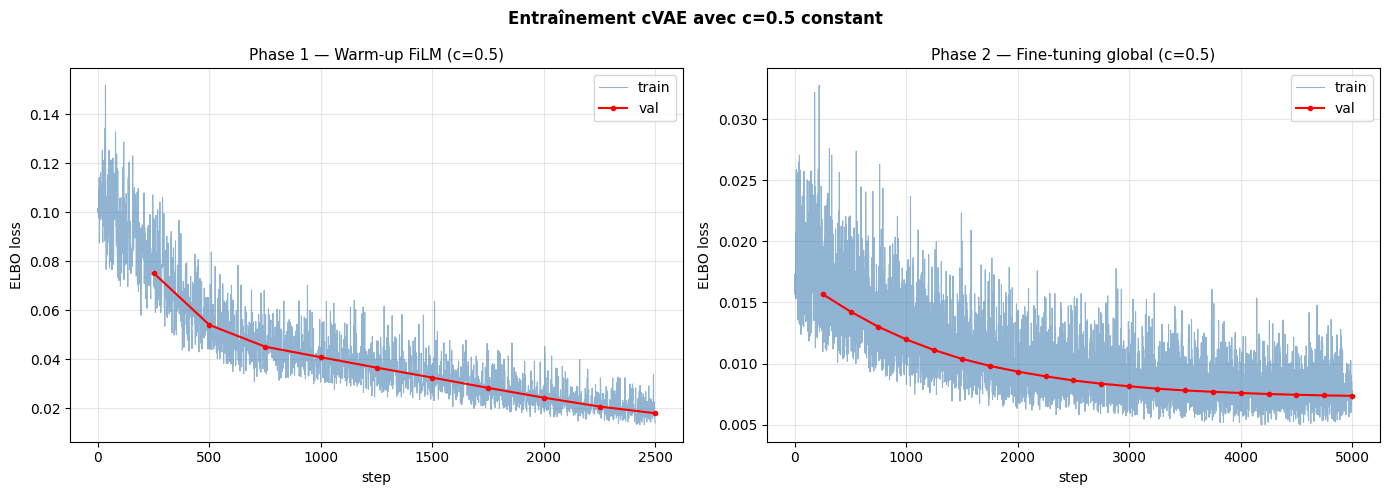

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Phase 1
ax = axes[0]
ax.plot(history_warmup["train"], color="steelblue", lw=0.8, alpha=0.6, label="train")
val_x = list(range(VAL_EVERY, VAL_EVERY * len(history_warmup["val"]) + 1, VAL_EVERY))
ax.plot(val_x, history_warmup["val"], "o-", color="red", ms=3, lw=1.5, label="val")
ax.set_title(f"Phase 1 — Warm-up FiLM (c={C_CONSTANT})", fontsize=11)
ax.set_xlabel("step")
ax.set_ylabel("ELBO loss")
ax.legend()
ax.grid(alpha=0.3)

# Phase 2
ax = axes[1]
ax.plot(history_ft["train"], color="steelblue", lw=0.8, alpha=0.6, label="train")
val_x2 = list(range(VAL_EVERY, VAL_EVERY * len(history_ft["val"]) + 1, VAL_EVERY))
ax.plot(val_x2, history_ft["val"], "o-", color="red", ms=3, lw=1.5, label="val")
ax.set_title(f"Phase 2 — Fine-tuning global (c={C_CONSTANT})", fontsize=11)
ax.set_xlabel("step")
ax.set_ylabel("ELBO loss")
ax.legend()
ax.grid(alpha=0.3)

fig.suptitle(f"Entraînement cVAE avec c={C_CONSTANT} constant", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Sauvegarde du checkpoint

In [9]:
torch.save({
    "model_state_dict": cvae_const.state_dict(),
    "ddconfig":         DDCONFIG,
    "embed_dim":        EMBED_DIM,
    "approach":         APPROACH,
    "c_constant":       C_CONSTANT,
    "warmup_steps":     step,
    "finetune_steps":   step_ft,
    "best_val_loss":    best_val_loss_ft,
}, CVAE_CONST_CKPT)

print(f"Checkpoint sauvegardé → {CVAE_CONST_CKPT}")
print(f"  Taille : {CVAE_CONST_CKPT.stat().st_size / 1e6:.1f} MB")

Checkpoint sauvegardé → outputs_theophile/06_Ablation_c_Constant/approach_B/quality_aware_vae_c_constant.pt
  Taille : 228.3 MB


## 9. Chargement du cVAE(c réel) pour comparaison

In [10]:
assert CVAE_REAL_CKPT.exists(), f"Checkpoint NB04 introuvable : {CVAE_REAL_CKPT}"

ckpt_real = torch.load(CVAE_REAL_CKPT, map_location="cpu", weights_only=False)
base_ae_real = AutoencoderKL2D(ddconfig=ckpt_real["ddconfig"], embed_dim=ckpt_real["embed_dim"],
                                apply_channel_ds=True)
cvae_real = QualityAwareAutoencoderKL(base_ae_real)
cvae_real.load_state_dict(ckpt_real["model_state_dict"])
cvae_real = cvae_real.to(DEVICE).eval()

cvae_const.eval()

print(f"cVAE(c réel)    chargé — val loss NB04 : {ckpt_real.get('best_val_loss', '?')}")
print(f"cVAE(c=0.5)     entraîné ici — val loss : {best_val_loss_ft:.6f}")

cVAE(c réel)    chargé — val loss NB04 : 0.007510275039821863
cVAE(c=0.5)     entraîné ici — val loss : 0.007351


## 10. Construction du jeu de test

In [11]:
test_sets = {}
for label in ["bad", "medium", "good"]:
    subset = df_labels[df_labels["quality_label"] == label]
    accessible = subset[subset["path"].apply(lambda p: Path(p).exists())]
    sampled = accessible.sample(min(N_TEST_PER_CLASS, len(accessible)), random_state=RANDOM_SEED)
    test_sets[label] = sampled.reset_index(drop=True)
    print(f"  {label:6s} : {len(sampled)} images")

df_test = pd.concat(test_sets.values(), ignore_index=True)
print(f"\nTotal test : {len(df_test)} images")

  bad    : 20 images
  medium : 20 images
  good   : 20 images

Total test : 60 images


## 11. Fonctions utilitaires

In [12]:
def load_tensor(path: str, size: int = IMG_SIZE) -> torch.Tensor:
    img = Image.open(path).convert("L").resize((size, size), Image.Resampling.BILINEAR)
    t = torch.from_numpy(np.asarray(img, np.float32) / 255.0)
    return (t.unsqueeze(0).unsqueeze(0) * 2.0 - 1.0)


def to_numpy(t: torch.Tensor) -> np.ndarray:
    return ((t.squeeze().cpu().numpy().clip(-1, 1) + 1) / 2)


def to_uint8(t: torch.Tensor) -> np.ndarray:
    return (to_numpy(t) * 255).astype(np.uint8)


def compute_metrics(original: torch.Tensor, reconstruction: torch.Tensor) -> dict:
    mse = float(F.mse_loss(reconstruction, original).item())
    orig_u8 = to_uint8(original)
    rec_u8 = to_uint8(reconstruction)
    ssim_val = float(ssim_fn(orig_u8, rec_u8, data_range=255))
    psnr_val = float(psnr_fn(orig_u8, rec_u8, data_range=255))
    haarpsi_val = _compute_haarpsi(orig_u8, rec_u8)
    return {"mse": mse, "ssim": ssim_val, "psnr": psnr_val, "haarpsi": haarpsi_val}


def _compute_haarpsi(ref: np.ndarray, deg: np.ndarray) -> float:
    try:
        import piq
        r_t = torch.from_numpy(ref.astype(np.float32)).unsqueeze(0).unsqueeze(0)
        d_t = torch.from_numpy(deg.astype(np.float32)).unsqueeze(0).unsqueeze(0)
        return float(piq.haarpsi(r_t, d_t, data_range=255.).item())
    except (ImportError, Exception):
        pass
    from scipy.ndimage import convolve, zoom
    C = 3e-4
    ref64, deg64 = ref.astype(np.float64) / 255.0, deg.astype(np.float64) / 255.0
    total_score, total_weight = 0.0, 0.0
    for scale in [1, 2]:
        r = zoom(ref64, 0.5, order=1) if scale > 1 else ref64
        d = zoom(deg64, 0.5, order=1) if scale > 1 else deg64
        for kernel in [np.array([[1, -1]], dtype=np.float64),
                       np.array([[1], [-1]], dtype=np.float64)]:
            cr = np.abs(convolve(r, kernel, mode="reflect"))
            cd = np.abs(convolve(d, kernel, mode="reflect"))
            sim = (2 * cr * cd + C) / (cr**2 + cd**2 + C)
            w = np.maximum(cr, cd)
            total_score += np.sum(w * sim)
            total_weight += np.sum(w)
    return float(total_score / (total_weight + 1e-10))


print("Fonctions utilitaires définies.")

Fonctions utilitaires définies.


## 12. Évaluation : cVAE(c réel) vs cVAE(c=0.5)

Les deux modèles reçoivent **le vrai score $c$** de chaque image à l'inférence.
La différence : l'un a été entraîné avec ce signal, l'autre avec un signal constant.

In [13]:
@torch.no_grad()
def evaluate_both(df: pd.DataFrame) -> pd.DataFrame:
    records = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Évaluation"):
        try:
            x = load_tensor(row["path"]).to(DEVICE)
            c = torch.tensor([row["quality_score"]], dtype=torch.float32, device=DEVICE)

            # cVAE entraîné avec c réel
            rec_real, _ = cvae_real(x, c, sample_posterior=False)
            m_real = compute_metrics(x, rec_real)

            # cVAE entraîné avec c=0.5 (mais on lui passe le vrai c à l'inférence)
            rec_const, _ = cvae_const(x, c, sample_posterior=False)
            m_const = compute_metrics(x, rec_const)

            records.append({
                "image_id":      row["image_id"],
                "path":          row["path"],
                "quality_label": row["quality_label"],
                "quality_score": row["quality_score"],
                **{f"real_{k}": v for k, v in m_real.items()},
                **{f"const_{k}": v for k, v in m_const.items()},
            })
        except Exception:
            pass
    return pd.DataFrame(records)


df_results = evaluate_both(df_test)
print(f"\nÉvaluation terminée : {len(df_results)} images")
print("\nMoyennes par classe :")
df_results.groupby("quality_label")[
    ["real_mse", "const_mse", "real_ssim", "const_ssim", "real_haarpsi", "const_haarpsi"]
].mean().round(5)

Évaluation: 100%|██████████| 60/60 [00:03<00:00, 17.00it/s]


Évaluation terminée : 60 images

Moyennes par classe :


,real_mse,const_mse,real_ssim,const_ssim,real_haarpsi,const_haarpsi
quality_label,,,,,,
bad,0.00215,0.00241,0.92415,0.92484,0.87313,0.87407
good,0.00375,0.00433,0.90491,0.90036,0.84309,0.83591
medium,0.00193,0.00196,0.92184,0.92214,0.87077,0.87029


## 13. Tableau récapitulatif avec tests de Wilcoxon

In [14]:
print("=" * 75)
print(f"{'ABLATION c CONSTANT — TABLEAU RÉCAPITULATIF':^75s}")
print(f"Approche : {APPROACH} | c constant à l'entraînement = {C_CONSTANT}")
print("=" * 75)

metrics_info = {
    "MSE":     ("real_mse",     "const_mse",     -1),
    "SSIM":    ("real_ssim",    "const_ssim",     1),
    "PSNR":    ("real_psnr",    "const_psnr",     1),
    "HAARPSI": ("real_haarpsi", "const_haarpsi",  1),
}

summary_rows = []

for metric_name, (col_real, col_const, direction) in metrics_info.items():
    arrow = "↓" if direction == -1 else "↑"
    print(f"\n  {metric_name} {arrow}")
    print(f"  {'Label':<8s}  {'cVAE(c réel)':>14s}  {'cVAE(c=0.5)':>14s}  {'Δ':>12s}  {'p-value':>8s}  {'Verdict':>12s}")
    print(f"  {'-'*75}")

    for label in ["bad", "medium", "good", "ALL"]:
        sub = df_results if label == "ALL" else df_results[df_results["quality_label"] == label]
        if len(sub) < 3:
            continue

        vals_real  = sub[col_real].values
        vals_const = sub[col_const].values
        mean_real  = np.mean(vals_real)
        mean_const = np.mean(vals_const)
        delta = mean_real - mean_const

        try:
            _, pval = stats.wilcoxon(vals_real, vals_const)
        except Exception:
            pval = float("nan")

        if direction == -1:
            winner = "c réel ✓" if mean_real < mean_const else "c=0.5 ✗"
        else:
            winner = "c réel ✓" if mean_real > mean_const else "c=0.5 ✗"

        sig = "*" if (not np.isnan(pval) and pval < 0.05) else ""
        print(f"  {label:<8s}  {mean_real:14.5f}  {mean_const:14.5f}  {delta:+12.5f}  {pval:8.4f}{sig}  {winner}")
        summary_rows.append({"metric": metric_name, "label": label,
                             "mean_real": mean_real, "mean_const": mean_const,
                             "delta": delta, "pval": pval, "winner": winner})

print("\n" + "=" * 75)

                ABLATION c CONSTANT — TABLEAU RÉCAPITULATIF                
Approche : B | c constant à l'entraînement = 0.5

  MSE ↓
  Label       cVAE(c réel)     cVAE(c=0.5)             Δ   p-value       Verdict
  ---------------------------------------------------------------------------
  bad              0.00215         0.00241      -0.00026    0.0037*  c réel ✓
  medium           0.00193         0.00196      -0.00003    0.9854  c réel ✓
  good             0.00375         0.00433      -0.00058    0.0004*  c réel ✓
  ALL              0.00261         0.00290      -0.00029    0.0000*  c réel ✓

  SSIM ↑
  Label       cVAE(c réel)     cVAE(c=0.5)             Δ   p-value       Verdict
  ---------------------------------------------------------------------------
  bad              0.92415         0.92484      -0.00069    0.0400*  c=0.5 ✗
  medium           0.92184         0.92214      -0.00030    0.1140  c=0.5 ✗
  good             0.90491         0.90036      +0.00455    0.0000*  c rée

## 14. Boxplots comparatifs par classe

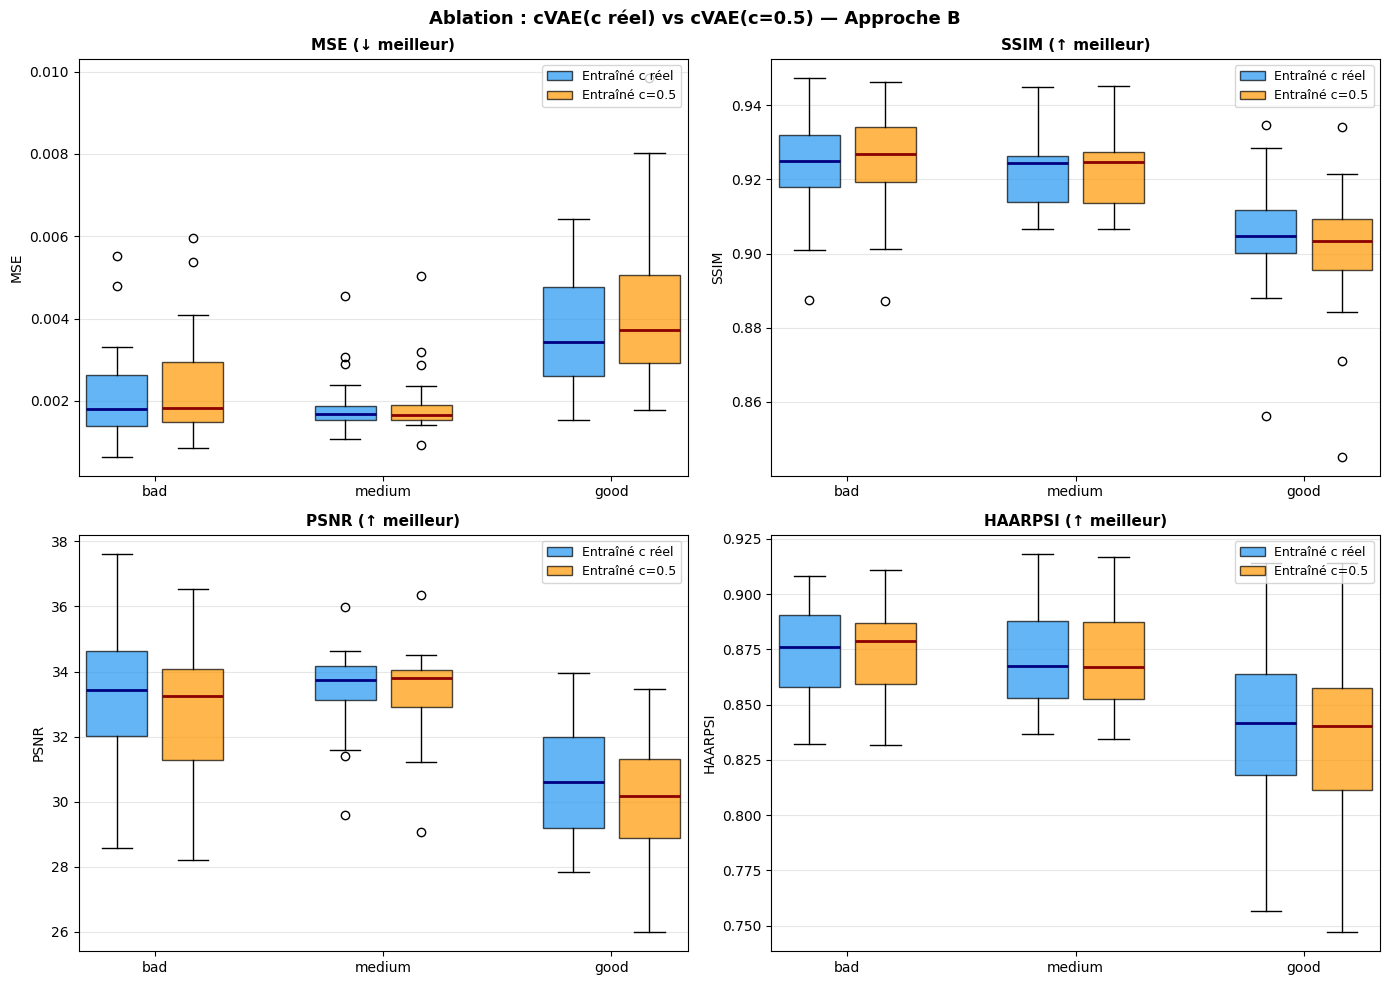

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
label_order = ["bad", "medium", "good"]

for idx, (metric_name, (col_real, col_const, direction)) in enumerate(metrics_info.items()):
    ax = axes[idx]
    arrow = "↓" if direction == -1 else "↑"
    data_real, data_const = [], []
    positions_real, positions_const = [], []

    for i, label in enumerate(label_order):
        sub = df_results[df_results["quality_label"] == label]
        data_real.append(sub[col_real].values)
        data_const.append(sub[col_const].values)
        positions_real.append(i * 3)
        positions_const.append(i * 3 + 1)

    bp1 = ax.boxplot(data_real, positions=positions_real, widths=0.8,
                     patch_artist=True, boxprops=dict(facecolor="#2196F3", alpha=0.7),
                     medianprops=dict(color="navy", lw=2))
    bp2 = ax.boxplot(data_const, positions=positions_const, widths=0.8,
                     patch_artist=True, boxprops=dict(facecolor="#FF9800", alpha=0.7),
                     medianprops=dict(color="darkred", lw=2))

    ax.set_xticks([i * 3 + 0.5 for i in range(len(label_order))])
    ax.set_xticklabels(label_order, fontsize=10)
    ax.set_title(f"{metric_name} ({arrow} meilleur)", fontsize=11, fontweight="bold")
    ax.set_ylabel(metric_name)
    ax.grid(axis="y", alpha=0.3)
    ax.legend([bp1["boxes"][0], bp2["boxes"][0]],
              ["Entraîné c réel", f"Entraîné c={C_CONSTANT}"],
              loc="upper right", fontsize=9)

fig.suptitle(f"Ablation : cVAE(c réel) vs cVAE(c={C_CONSTANT}) — Approche {APPROACH}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. Différence par image : Δ métrique vs score de qualité

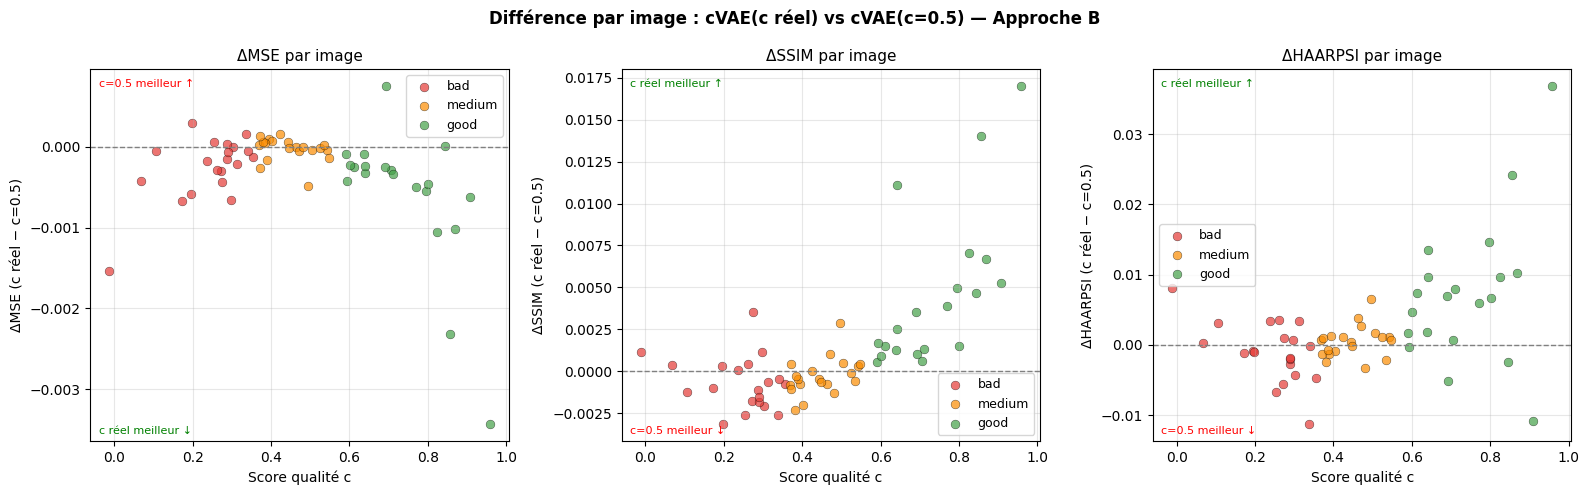

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
label_colors = {"bad": "#E53935", "medium": "#FB8C00", "good": "#43A047"}

for idx, (metric_name, col_real, col_const, direction) in enumerate([
    ("MSE", "real_mse", "const_mse", -1),
    ("SSIM", "real_ssim", "const_ssim", 1),
    ("HAARPSI", "real_haarpsi", "const_haarpsi", 1),
]):
    ax = axes[idx]
    delta_col = f"delta_{metric_name.lower()}"
    df_results[delta_col] = df_results[col_real] - df_results[col_const]

    for label in label_order:
        sub = df_results[df_results["quality_label"] == label]
        ax.scatter(sub["quality_score"], sub[delta_col],
                   c=label_colors[label], alpha=0.7, s=40, label=label, edgecolors="k", lw=0.3)

    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_xlabel("Score qualité c", fontsize=10)
    ax.set_ylabel(f"Δ{metric_name} (c réel − c=0.5)", fontsize=10)
    ax.set_title(f"Δ{metric_name} par image", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    if direction == -1:
        ax.annotate("c réel meilleur ↓", xy=(0.02, 0.02), xycoords="axes fraction",
                    fontsize=8, color="green")
        ax.annotate("c=0.5 meilleur ↑", xy=(0.02, 0.95), xycoords="axes fraction",
                    fontsize=8, color="red")
    else:
        ax.annotate("c réel meilleur ↑", xy=(0.02, 0.95), xycoords="axes fraction",
                    fontsize=8, color="green")
        ax.annotate("c=0.5 meilleur ↓", xy=(0.02, 0.02), xycoords="axes fraction",
                    fontsize=8, color="red")

fig.suptitle(f"Différence par image : cVAE(c réel) vs cVAE(c={C_CONSTANT}) — Approche {APPROACH}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_delta_per_image.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Galerie visuelle

Pour quelques images (bad + good), on montre :
Original | Rec cVAE(c réel) | Rec cVAE(c=0.5) | Carte de différence

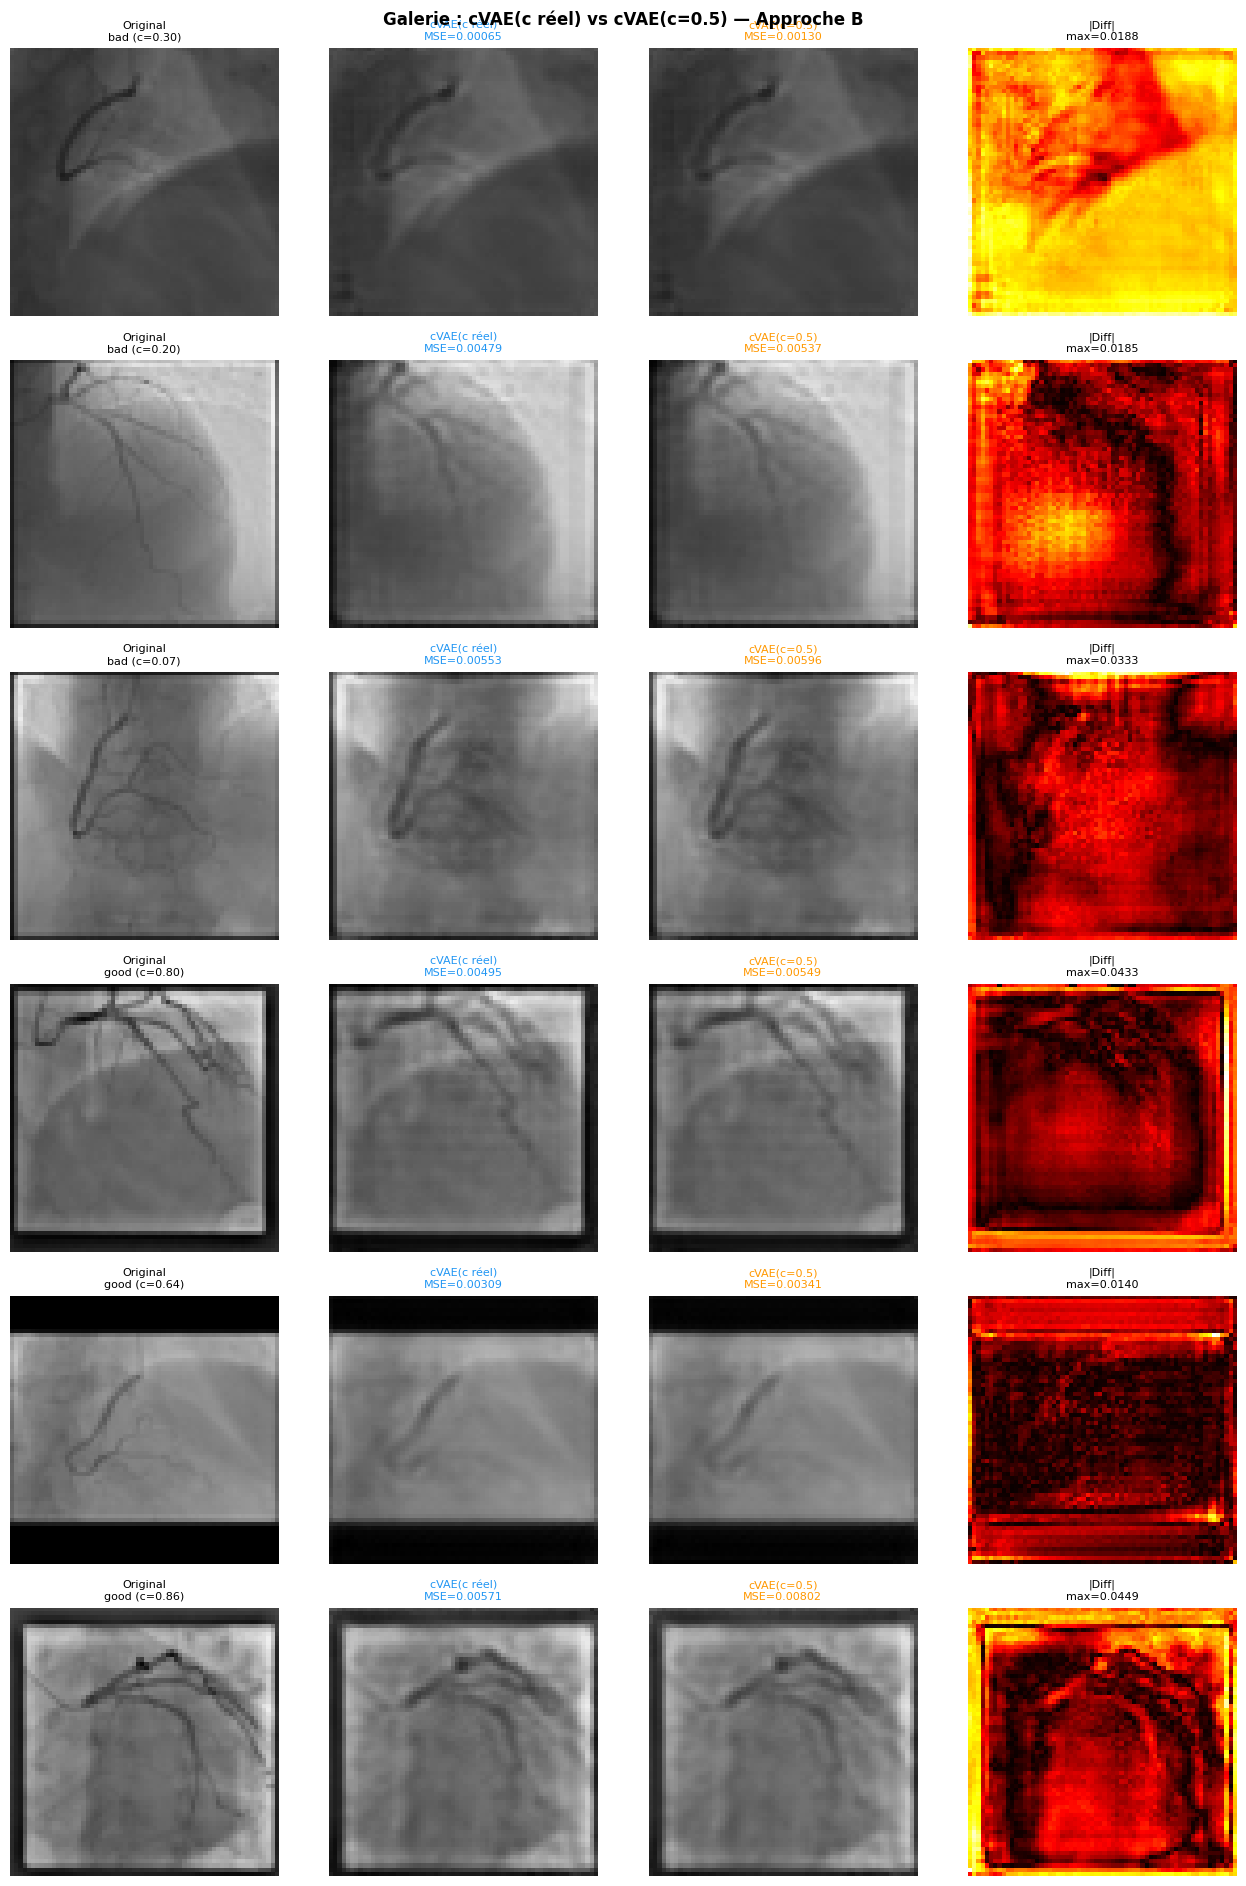

In [17]:
@torch.no_grad()
def gallery(df: pd.DataFrame, n_per_class: int = 3):
    samples = []
    for label in ["bad", "good"]:
        sub = df[df["quality_label"] == label].head(n_per_class)
        samples.append(sub)
    samples = pd.concat(samples, ignore_index=True)

    n_rows = len(samples)
    fig, axes = plt.subplots(n_rows, 4, figsize=(13, 3.2 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for row_idx, (_, row) in enumerate(samples.iterrows()):
        x = load_tensor(row["path"]).to(DEVICE)
        c = torch.tensor([row["quality_score"]], dtype=torch.float32, device=DEVICE)
        orig_np = to_numpy(x)

        rec_real_t, _ = cvae_real(x, c, sample_posterior=False)
        rec_const_t, _ = cvae_const(x, c, sample_posterior=False)
        rec_real_np = to_numpy(rec_real_t)
        rec_const_np = to_numpy(rec_const_t)

        mse_real = float(F.mse_loss(rec_real_t, x).item())
        mse_const = float(F.mse_loss(rec_const_t, x).item())

        axes[row_idx, 0].imshow(orig_np, cmap="gray", vmin=0, vmax=1)
        axes[row_idx, 0].set_title(f"Original\n{row['quality_label']} (c={row['quality_score']:.2f})", fontsize=8)
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(rec_real_np, cmap="gray", vmin=0, vmax=1)
        axes[row_idx, 1].set_title(f"cVAE(c réel)\nMSE={mse_real:.5f}", fontsize=8, color="#2196F3")
        axes[row_idx, 1].axis("off")

        axes[row_idx, 2].imshow(rec_const_np, cmap="gray", vmin=0, vmax=1)
        axes[row_idx, 2].set_title(f"cVAE(c=0.5)\nMSE={mse_const:.5f}", fontsize=8, color="#FF9800")
        axes[row_idx, 2].axis("off")

        diff = np.abs(rec_real_np - rec_const_np)
        axes[row_idx, 3].imshow(diff, cmap="hot", vmin=0, vmax=diff.max() + 1e-6)
        axes[row_idx, 3].set_title(f"|Diff|\nmax={diff.max():.4f}", fontsize=8)
        axes[row_idx, 3].axis("off")

    fig.suptitle(f"Galerie : cVAE(c réel) vs cVAE(c={C_CONSTANT}) — Approche {APPROACH}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "06_gallery.png", dpi=150, bbox_inches="tight")
    plt.show()


gallery(df_results, n_per_class=3)

## 17. Dégradations synthétiques

In [18]:
from scipy.ndimage import uniform_filter as uf, gaussian_filter

def add_gaussian_noise(x, sigma):
    return (x + torch.randn_like(x) * sigma).clamp(-1, 1)

def add_motion_blur(x, kernel_size, direction="horizontal"):
    if direction == "horizontal":
        k = torch.ones(1, 1, 1, kernel_size, device=x.device) / kernel_size
        pad = (kernel_size // 2, kernel_size // 2, 0, 0)
    else:
        k = torch.ones(1, 1, kernel_size, 1, device=x.device) / kernel_size
        pad = (0, 0, kernel_size // 2, kernel_size // 2)
    return F.conv2d(F.pad(x, pad, mode="reflect"), k).clamp(-1, 1)

def inline_quality_score(img_tensor):
    from scipy.ndimage import laplace, sobel
    img = img_tensor.squeeze().cpu().numpy().astype(np.float64)
    img = (img + 1) / 2
    img_smooth = gaussian_filter(img, sigma=1.0)
    mu = uf(img_smooth, size=7)
    sigma = np.sqrt(np.maximum(uf(img_smooth**2, size=7) - mu**2, 0))
    mscn = (img_smooth - mu) / (sigma + 1.0)
    lap_var = float(laplace(mscn).var())
    Gx, Gy = sobel(mscn, axis=1), sobel(mscn, axis=0)
    tenengrad = float(np.sqrt(Gx**2 + Gy**2).mean())
    noise_energy = float(np.mean((img - img_smooth)**2))
    noise_penalty = float(np.clip(1.0 - noise_energy / 0.005, 0.0, 1.0))
    raw_score = np.clip(0.5 * (lap_var / 0.01) + 0.5 * (tenengrad / 0.5), 0.0, 1.0)
    return float(raw_score * noise_penalty)


DEGRADATION_GRID = [
    {"name": "Propre",        "fn": lambda x: x},
    {"name": "Bruit σ=0.05", "fn": lambda x: add_gaussian_noise(x, 0.05)},
    {"name": "Bruit σ=0.10", "fn": lambda x: add_gaussian_noise(x, 0.10)},
    {"name": "Bruit σ=0.20", "fn": lambda x: add_gaussian_noise(x, 0.20)},
    {"name": "Flou H k=5",   "fn": lambda x: add_motion_blur(x, 5, "horizontal")},
    {"name": "Flou V k=5",   "fn": lambda x: add_motion_blur(x, 5, "vertical")},
    {"name": "Flou V k=11",  "fn": lambda x: add_motion_blur(x, 11, "vertical")},
]

print(f"{len(DEGRADATION_GRID)} types de dégradations.")

7 types de dégradations.


In [19]:
@torch.no_grad()
def evaluate_synthetic(df_good):
    records = []
    sample = df_good.sample(min(N_TEST_PER_CLASS, len(df_good)), random_state=RANDOM_SEED)
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Synth"):
        try:
            x_clean = load_tensor(row["path"]).to(DEVICE)
        except Exception:
            continue
        for d in DEGRADATION_GRID:
            x_deg = d["fn"](x_clean)
            c_inline = torch.tensor([inline_quality_score(x_deg)], dtype=torch.float32, device=DEVICE)

            rec_real, _ = cvae_real(x_deg, c_inline, sample_posterior=False)
            rec_const, _ = cvae_const(x_deg, c_inline, sample_posterior=False)

            m_real = compute_metrics(x_clean, rec_real)
            m_const = compute_metrics(x_clean, rec_const)

            records.append({
                "image_id": row["image_id"], "degradation": d["name"],
                "c_inline": float(c_inline.item()),
                **{f"real_{k}": v for k, v in m_real.items()},
                **{f"const_{k}": v for k, v in m_const.items()},
            })
    return pd.DataFrame(records)


df_synth = evaluate_synthetic(test_sets.get("good", df_test[df_test["quality_label"] == "good"]))
print(f"Évaluations synthétiques : {len(df_synth)} entrées")

Synth: 100%|██████████| 20/20 [00:05<00:00,  3.42it/s]

Évaluations synthétiques : 140 entrées


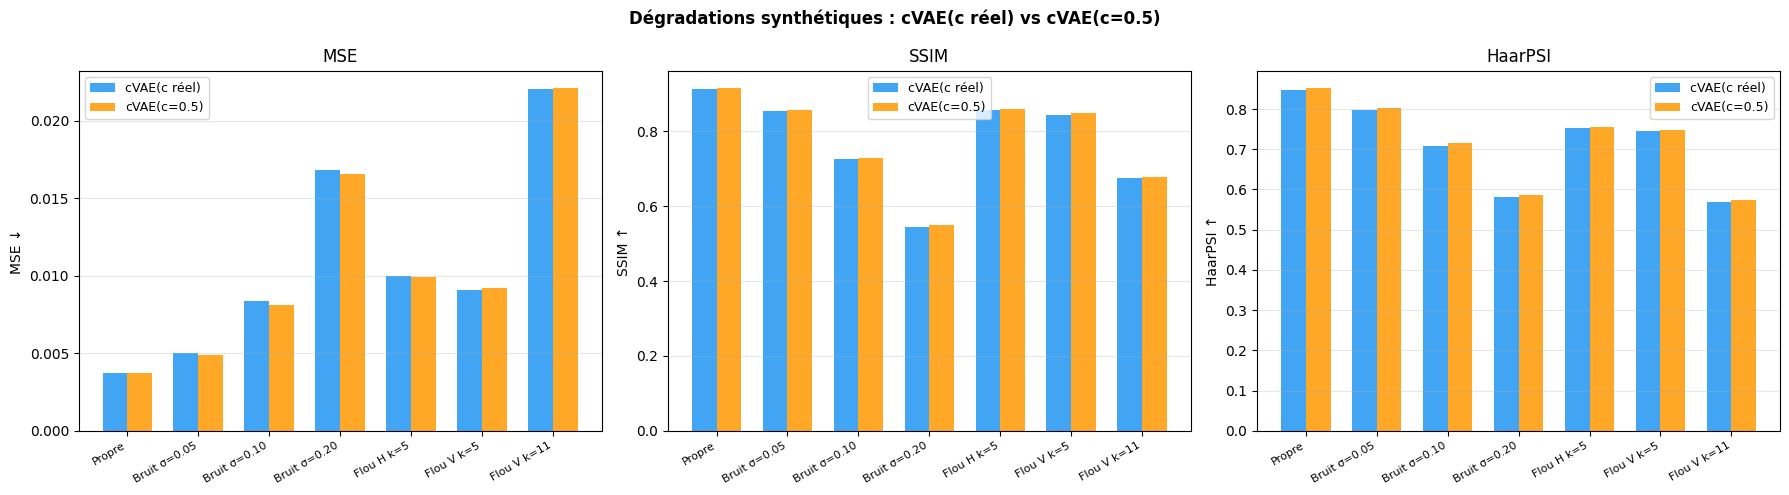

In [20]:
if len(df_synth) > 0:
    order = [d["name"] for d in DEGRADATION_GRID]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (m_real, m_const), ylabel in zip(
        axes,
        [("real_mse", "const_mse"), ("real_ssim", "const_ssim"), ("real_haarpsi", "const_haarpsi")],
        ["MSE ↓", "SSIM ↑", "HaarPSI ↑"],
    ):
        g = df_synth.groupby("degradation")[[m_real, m_const]].mean().reindex(order)
        x_pos = np.arange(len(order))
        width = 0.35
        ax.bar(x_pos - width/2, g[m_real],  width, label="cVAE(c réel)", color="#2196F3", alpha=0.85)
        ax.bar(x_pos + width/2, g[m_const], width, label=f"cVAE(c={C_CONSTANT})", color="#FF9800", alpha=0.85)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(order, rotation=30, ha="right", fontsize=8)
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)
        ax.set_title(ylabel.split(" ")[0])
        ax.grid(axis="y", alpha=0.3)

    fig.suptitle(f"Dégradations synthétiques : cVAE(c réel) vs cVAE(c={C_CONSTANT})",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "06_synthetic_barplot.png", dpi=150, bbox_inches="tight")
    plt.show()

## 18. Export

In [21]:
df_results.to_csv(OUTPUT_DIR / "06_ablation_results.csv", index=False)
if len(df_synth) > 0:
    df_synth.to_csv(OUTPUT_DIR / "06_synthetic_results.csv", index=False)

print("Fichiers exportés :")
for f in sorted(OUTPUT_DIR.glob("06_*")):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

Fichiers exportés :
  06_ablation_results.csv  (20.9 KB)
  06_boxplots.png  (131.0 KB)
  06_delta_per_image.png  (163.8 KB)
  06_gallery.png  (333.9 KB)
  06_synthetic_barplot.png  (76.9 KB)
  06_synthetic_results.csv  (25.8 KB)
  06_training_curves.png  (152.9 KB)


## 19. Conclusion — calculée dynamiquement

In [22]:
from pipeline_config import get_approach_config

cfg = get_approach_config()
print("=" * 75)
print(f"{'CONCLUSION — ABLATION PAR c CONSTANT':^75s}")
print(f"Approche : {APPROACH} — {cfg['name']}")
print("=" * 75)

print(f"\nProtocole :")
print(f"  • cVAE(c réel)  = entraîné avec les vrais scores qualité (NB04)")
print(f"  • cVAE(c={C_CONSTANT})  = entraîné avec c={C_CONSTANT} constant (ce notebook)")
print(f"  • Même architecture, mêmes données, même budget ({step + step_ft} steps)")
print(f"  • Seule variable : le signal c reçu pendant l'entraînement")

n_real_wins, n_const_wins, n_tests = 0, 0, 0
for metric_name, (col_real, col_const, direction) in metrics_info.items():
    for label in ["bad", "medium", "good"]:
        sub = df_results[df_results["quality_label"] == label]
        if len(sub) < 3:
            continue
        mean_r = sub[col_real].mean()
        mean_c = sub[col_const].mean()
        winner = ("real" if mean_r < mean_c else "const") if direction == -1 else \
                 ("real" if mean_r > mean_c else "const")
        if winner == "real":
            n_real_wins += 1
        else:
            n_const_wins += 1
        n_tests += 1

print(f"\nRésultat : cVAE(c réel) gagne {n_real_wins}/{n_tests}, cVAE(c=0.5) gagne {n_const_wins}/{n_tests}")

if n_real_wins > n_const_wins:
    print(f"\n→ CONCLUSION : Le signal c (approche {APPROACH}) contient de l'information UTILE")
    print(f"  pour l'apprentissage du cVAE. Le modèle exploite effectivement la qualité")
    print(f"  des images pour apprendre de meilleures représentations.")
elif n_const_wins > n_real_wins:
    print(f"\n→ CONCLUSION : Le signal c (approche {APPROACH}) N'APPORTE PAS d'information utile")
    print(f"  à l'apprentissage. Un c constant donne des résultats équivalents ou meilleurs,")
    print(f"  ce qui signifie que le score de qualité ne guide pas utilement la reconstruction.")
else:
    print(f"\n→ CONCLUSION : Résultats non concluants (égalité).")

print("\n" + "=" * 75)

                   CONCLUSION — ABLATION PAR c CONSTANT                    
Approche : B — PCA (PC1)

Protocole :
  • cVAE(c réel)  = entraîné avec les vrais scores qualité (NB04)
  • cVAE(c=0.5)  = entraîné avec c=0.5 constant (ce notebook)
  • Même architecture, mêmes données, même budget (7500 steps)
  • Seule variable : le signal c reçu pendant l'entraînement

Résultat : cVAE(c réel) gagne 9/12, cVAE(c=0.5) gagne 3/12

→ CONCLUSION : Le signal c (approche B) contient de l'information UTILE
  pour l'apprentissage du cVAE. Le modèle exploite effectivement la qualité
  des images pour apprendre de meilleures représentations.

